<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)


В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [ ]:
!pip install datasets

Импорт необходимых библиотек

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [ ]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
dataset.cache_files

{'train': [{'filename': '/root/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb-train.arrow'}],
 'test': [{'filename': '/root/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb-test.arrow'}],
 'unsupervised': [{'filename': '/root/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb-unsupervised.arrow'}]}

In [ ]:
dataset.num_columns


{'train': 2, 'test': 2, 'unsupervised': 2}

In [ ]:
dataset.num_rows

{'train': 25000, 'test': 25000, 'unsupervised': 50000}

In [ ]:
dataset.shape

{'train': (25000, 2), 'test': (25000, 2), 'unsupervised': (50000, 2)}

In [ ]:
first_example = dataset['train'][0]
print(first_example)

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [ ]:
train_sentences = []
word_threshold = 32

for sentence in tqdm(dataset['train']['text']):
  train_sentences.extend(
      [x.lower() for x in sent_tokenize(sentence, language='english') if len(word_tokenize(x)) < word_threshold])
# Получить отдельные предложения и поместить их в sentences

  0%|          | 0/25000 [00:00<?, ?it/s]

In [ ]:
print("Всего предложений:", len(train_sentences))

Всего предложений: 198801


Посчитаем для каждого слова его встречаемость.

In [ ]:
words = Counter()

# Расчет встречаемости слов
for sentence in tqdm(train_sentences):
    #разбиваем предложения на слова
    words_t = word_tokenize(sentence)
    #обновляем счетчик
    words.update(words_t)

  0%|          | 0/198801 [00:00<?, ?it/s]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [ ]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

# Наполнение словаря
most_common_words = [word for word, _ in words.most_common(vocab_size)]
vocab.update(most_common_words)

In [ ]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [ ]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [ ]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [ ]:
class WordDataset:
    def __init__(self, sentences, word2ind):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        sentence = self.data[idx]
        tokenized = [self.bos_id]
        words = word_tokenize(sentence.lower())
        tokenized += [word2ind.get(w, self.unk_id) for w in words]
        tokenized += [self.eos_id]
        return tokenized

    def __len__(self) -> int:
        return len(self.data)

In [ ]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [ ]:
batch_size = 128
pad_id = word2ind['<pad>']

# Разделяем train данные на train (80%) и validation (20%)
train_sentences, eval_sentences = train_test_split(
    train_sentences, test_size=0.2, random_state=42
)

# Шаг 2: Для проверки качества после обучения возьмем test данные из датасета (реальные тестовые данные)
test_sentences = []
for sentence in tqdm(dataset['test']['text']):
    test_sentences.extend(
        [x.lower() for x in sent_tokenize(sentence, language='english') if len(word_tokenize(x)) < word_threshold]
    )

print(f"Train данные (80% от train split): {len(train_sentences)} предложений")
print(f"Validation данные (20% от train split): {len(eval_sentences)} предложений")
print(f"Test данные (реальные из датасета): {len(test_sentences)} предложений")

# Создаем датасеты
train_dataset = WordDataset(train_sentences, word2ind)
eval_dataset = WordDataset(eval_sentences, word2ind)
test_dataset = WordDataset(test_sentences, word2ind)

# Создаем даталоадеры
train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size, shuffle=True
)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size
)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size
)

  0%|          | 0/25000 [00:00<?, ?it/s]

Train данные (80% от train split): 159040 предложений
Validation данные (20% от train split): 39761 предложений
Test данные (реальные из датасета): 195564 предложений


In [ ]:
print(f"Количество батчей в train: {len(train_dataloader)}")
print(f"Количество батчей в eval: {len(eval_dataloader)}")
print(f"Количество батчей в test: {len(test_dataloader)}")

Количество батчей в train: 1243
Количество батчей в eval: 311
Количество батчей в test: 1528


## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [ ]:
def evaluate(model, criterion, dataloader, device='cuda') -> float:
    model.eval()
    total_loss = 0
    total_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            # Явно перемещаем данные на device
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)

            # Forward pass
            logits = model(input_ids)

            # Вычисляем loss
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                target_ids.reshape(-1)
            )

            # Суммируем loss (без exp)
            total_loss += loss.item()
            total_batches += 1

    # Вычисляем средний loss и перплексию
    avg_loss = total_loss / total_batches
    perplexity = torch.exp(torch.tensor(avg_loss)).item()

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

    train_losses = []
    val_perplexities = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits.reshape(-1, logits.size(-1)),
                           target_ids.reshape(-1)
                           )
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Валидация
        val_perp = evaluate(model, criterion, val_loader)
        val_perplexities.append(val_perp)

        print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f}, Val Perplexity = {val_perp:.2f}')

    return train_losses, val_perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

# **Многослойный GRU с dropout**

Архитектура:
1. Embedding Layer (256) - Преобразует слова в векторы
2. Dropout (0.2) - Регуляризация эмбеддингов
3. 2-х слойная GRU (hidden_size=512, dropout=0.4) - Обработка последовательности
4. LayerNorm (512) + Dropout (0.4) - Нормализация и регуляризация
5. FC Layer (512 → 256) + ReLU - Промежуточное преобразование
6. LayerNorm (256) + Dropout (0.4) - Вторая нормализация
7. FC Layer (256 → vocab_size) - Выходной слой (вероятности слов)

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=word2ind['<pad>'])

        # Добавляем dropout на вход эмбеддингов
        self.embedding_dropout = nn.Dropout(0.2)

        # GRU с dropout между слоями
        self.gru = nn.GRU(
            embed_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.layernorm1 = nn.LayerNorm(hidden_dim)
        self.layernorm2 = nn.LayerNorm(hidden_dim // 2)
        self.dropout = nn.Dropout(dropout)

        # Добавляем промежуточный слой для большего capacity
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, vocab_size)
        self.activation = nn.ReLU()

    def forward(self, x):
        # Эмбеддинги с dropout
        embedded = self.embedding_dropout(self.embedding(x))

        # GRU
        gru_out, _ = self.gru(embedded)

        # LayerNorm + Dropout
        gru_out = self.layernorm1(gru_out)
        gru_out = self.dropout(gru_out)

        # Дополнительные слои
        hidden = self.fc1(gru_out)
        hidden = self.activation(hidden)
        hidden = self.layernorm2(hidden)
        hidden = self.dropout(hidden)

        logits = self.fc2(hidden)
        return logits

In [ ]:
model = GRUModel(
    vocab_size=len(vocab),
    embed_dim=256,      # размер эмбеддингов
    hidden_dim=512,     # размер скрытого состояния
    num_layers=2,       # количество слоев
    dropout=0.4         # dropout rate
).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0.01  # L2 регуляризация
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,      # умножаем LR на 0.5
    patience=2,      # ждем 2 эпохи без улучшения
    min_lr=1e-6      # минимальный LR
)

In [ ]:
num_epochs = 20
train_losses = []
val_perplexities = []

# Для early stopping
best_val_perp = float('inf')
best_epoch = 0
patience = 3  # сколько эпох ждать улучшения
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    epoch_losses = []
    model.train()

    # Training loop
    for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
        optimizer.zero_grad()
        logits = model(batch['input_ids'])
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            batch['target_ids'].reshape(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    train_losses.append(avg_loss)

    # Validation
    val_perp = evaluate(model, criterion, eval_dataloader)
    scheduler.step(val_perp)
    val_perplexities.append(val_perp)

    print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f}, Val Perplexity = {val_perp:.2f}')

    # early stopping
    if val_perp < best_val_perp:
        best_val_perp = val_perp
        best_epoch = epoch + 1
        patience_counter = 0
        # Сохраняем лучшую модель
        best_model_state = model.state_dict().copy()
        print(f'New best model! Perplexity: {val_perp:.2f}')
    else:
        patience_counter += 1
        print(f'No improvement for {patience_counter} epochs')

    # Останавливаем обучение если нет улучшений
    if patience_counter >= patience:
        print(f'\n  Early stopping triggered at epoch {epoch+1}')
        print(f'   Best validation perplexity: {best_val_perp:.2f} (epoch {best_epoch})')
        break

# Загружаем лучшую модель
model.load_state_dict(best_model_state)
print(f'\n Using best model from epoch {best_epoch}')
print(f'   Best validation perplexity: {best_val_perp:.2f}')

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: Loss = 5.3923, Val Perplexity = 137.46
New best model! Perplexity: 137.46


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: Loss = 4.9619, Val Perplexity = 117.71
New best model! Perplexity: 117.71


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Epoch 18: Loss = 4.3902, Val Perplexity = 89.54
No improvement for 1 epochs


Training epoch 18::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 19: Loss = 4.3797, Val Perplexity = 89.36
New best model! Perplexity: 89.36


Training epoch 19::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 20: Loss = 4.3694, Val Perplexity = 88.91
New best model! Perplexity: 88.91

 Using best model from epoch 20
   Best validation perplexity: 88.91


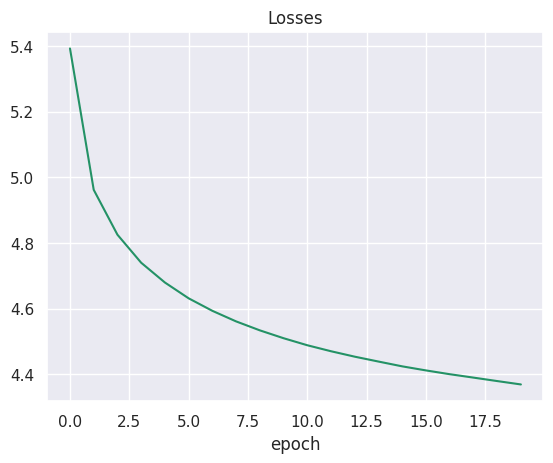

In [ ]:
plt.plot(np.arange(len(train_losses)), train_losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

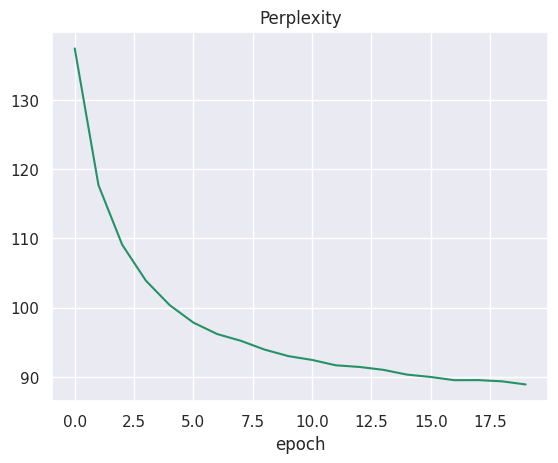

In [ ]:
plt.plot(np.arange(len(val_perplexities)), val_perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [ ]:
model.load_state_dict(best_model_state)

# Функция тестирования
def test_model(model, test_dataloader, criterion, device='cuda'):
    model.eval()
    total_loss = 0
    total_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc='Testing'):
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            logits = model(input_ids)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                target_ids.reshape(-1)
            )
            total_loss += loss.item()
            total_batches += 1

    avg_loss = total_loss / total_batches
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return perplexity, avg_loss

# Запуск тестирования
test_perp, test_loss = test_model(model, test_dataloader, criterion, device)

print("\n" + "="*50)
print("FINAL TEST RESULTS")
print("="*50)
print(f"Best Validation Perplexity: {best_val_perp:.2f}")
print(f"Test Perplexity: {test_perp:.2f}")
print(f"Test Loss: {test_loss:.4f}")
print("="*50)

Testing:   0%|          | 0/1528 [00:00<?, ?it/s]


FINAL TEST RESULTS
Best Validation Perplexity: 88.91
Test Perplexity: 81.60
Test Loss: 4.4018


### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

Архитектура:
1. Embedding Layer (256) - Преобразует слова в векторы
2. Dropout (0.2) - Регуляризация эмбеддингов
3. 2-х слойная LSTM (hidden_size=512, dropout=0.4) - Обработка последовательности
4. LayerNorm (512) + Dropout (0.4) - Нормализация и регуляризация
5. FC Layer (512 → 512) + GELU - Промежуточное преобразование
6. Dropout (0.4) → Регуляризация
7. FC Layer (512 → vocab_size) - Выходной слой (вероятности слов)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=word2ind['<pad>'])
        self.embedding_dropout = nn.Dropout(0.2)

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0
        )


        self.layernorm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

        # Промежуточные слои
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, vocab_size)
        self.activation = nn.GELU()  # GELU часто лучше ReLU

    def forward(self, x):
        embedded = self.embedding_dropout(self.embedding(x))
        lstm_out, _ = self.lstm(embedded)  # [batch, seq_len, hidden_dim*2]
        lstm_out = self.layernorm(lstm_out)
        lstm_out = self.dropout(lstm_out)

        hidden = self.fc1(lstm_out)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)

        logits = self.fc2(hidden)
        return logits

In [ ]:
model = LSTMModel(
    vocab_size=len(vocab),
    embed_dim=256,      # размер эмбеддингов
    hidden_dim=512,     # размер скрытого состояния
    num_layers=2,       # количество слоев
    dropout=0.4         # dropout rate
).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0.01  # L2 регуляризация
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,      # умножаем LR на 0.5
    patience=2,      # ждем 2 эпохи без улучшения
    min_lr=1e-6      # минимальный LR
)

In [ ]:
num_epochs = 20
train_losses = []
val_perplexities = []

# Для early stopping
best_val_perp = float('inf')
best_epoch = 0
patience = 3  # сколько эпох ждать улучшения
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    epoch_losses = []
    model.train()

    # Training loop
    for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
        optimizer.zero_grad()
        logits = model(batch['input_ids'])
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            batch['target_ids'].reshape(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    train_losses.append(avg_loss)

    # Validation
    val_perp = evaluate(model, criterion, eval_dataloader)
    scheduler.step(val_perp)
    val_perplexities.append(val_perp)

    print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f}, Val Perplexity = {val_perp:.2f}')

    # early stopping
    if val_perp < best_val_perp:
        best_val_perp = val_perp
        best_epoch = epoch + 1
        patience_counter = 0
        # Сохраняем лучшую модель
        best_model_state = model.state_dict().copy()
        print(f'New best model! Perplexity: {val_perp:.2f}')
    else:
        patience_counter += 1
        print(f'No improvement for {patience_counter} epochs')

    # Останавливаем обучение если нет улучшений
    if patience_counter >= patience:
        print(f'\n  Early stopping triggered at epoch {epoch+1}')
        print(f'   Best validation perplexity: {best_val_perp:.2f} (epoch {best_epoch})')
        break

# Загружаем лучшую модель
model.load_state_dict(best_model_state)
print(f'\n Using best model from epoch {best_epoch}')
print(f'   Best validation perplexity: {best_val_perp:.2f}')

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 1: Loss = 5.3272, Val Perplexity = 131.24
New best model! Perplexity: 131.24


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 2: Loss = 4.8835, Val Perplexity = 110.46
New best model! Perplexity: 110.46


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Epoch 18: Loss = 4.1079, Val Perplexity = 79.37
No improvement for 1 epochs


Training epoch 18::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 19: Loss = 4.0916, Val Perplexity = 79.02
New best model! Perplexity: 79.02


Training epoch 19::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch 20: Loss = 4.0756, Val Perplexity = 78.97
New best model! Perplexity: 78.97

 Using best model from epoch 20
   Best validation perplexity: 78.97


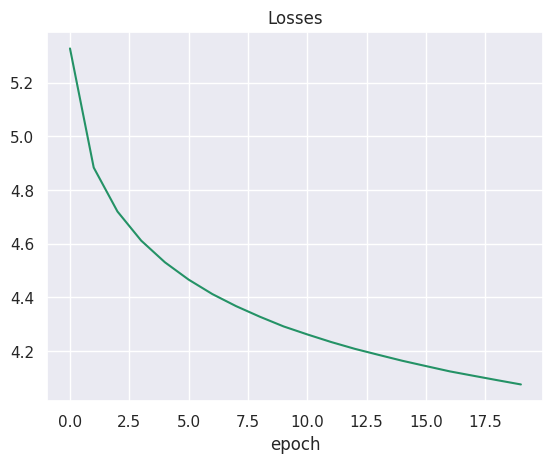

In [ ]:
plt.plot(np.arange(len(train_losses)), train_losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

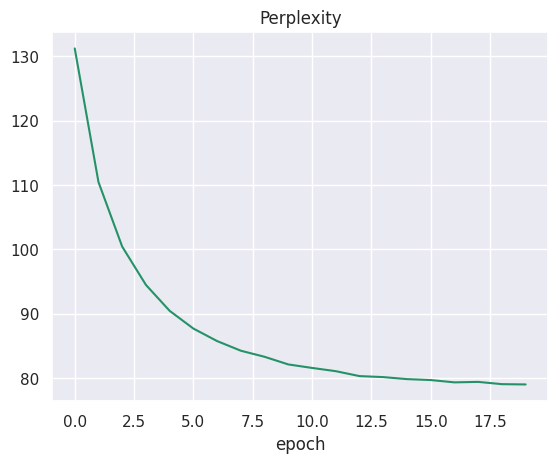

In [ ]:
plt.plot(np.arange(len(val_perplexities)), val_perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [ ]:
model.load_state_dict(best_model_state)

# Функция тестирования
def test_model(model, test_dataloader, criterion, device='cuda'):
    model.eval()
    total_loss = 0
    total_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc='Testing'):
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            logits = model(input_ids)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                target_ids.reshape(-1)
            )
            total_loss += loss.item()
            total_batches += 1

    avg_loss = total_loss / total_batches
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return perplexity, avg_loss

# Запуск тестирования
test_perp, test_loss = test_model(model, test_dataloader, criterion, device)

print("\n" + "="*50)
print("FINAL TEST RESULTS")
print("="*50)
print(f"Best Validation Perplexity: {best_val_perp:.2f}")
print(f"Test Perplexity: {test_perp:.2f}")
print(f"Test Loss: {test_loss:.4f}")
print("="*50)

Testing:   0%|          | 0/1528 [00:00<?, ?it/s]


FINAL TEST RESULTS
Best Validation Perplexity: 78.97
Test Perplexity: 73.65
Test Loss: 4.2993


### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

# **Таблица результатов**

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# Данные из вашего ноутбука
epochs = list(range(1, 21))

# GRU результаты
gru_train_losses = [5.3923, 4.9619, 4.8252, 4.7399, 4.6797, 4.6316, 4.5935, 4.5613, 4.5341, 4.5101,
                    4.4887, 4.4705, 4.4539, 4.4391, 4.4245, 4.4121, 4.4006, 4.3902, 4.3797, 4.3694]
gru_val_perps = [137.46, 117.71, 109.09, 103.90, 100.37, 97.84, 96.19, 95.22, 93.95, 93.01,
                 92.45, 91.68, 91.44, 91.02, 90.33, 89.99, 89.53, 89.54, 89.36, 88.91]

# LSTM результаты
lstm_train_losses = [5.3272, 4.8835, 4.7199, 4.6114, 4.5307, 4.4661, 4.4122, 4.3673, 4.3279, 4.2918,
                     4.2620, 4.2338, 4.2083, 4.1859, 4.1639, 4.1441, 4.1244, 4.1079, 4.0916, 4.0756]
lstm_val_perps = [131.24, 110.46, 100.41, 94.46, 90.42, 87.67, 85.72, 84.22, 83.27, 82.09,
                  81.54, 81.04, 80.27, 80.12, 79.80, 79.66, 79.30, 79.37, 79.02, 78.97]

# Тестовые результаты
gru_test_ppl = 81.60
lstm_test_ppl = 73.65

# Лучшие результаты
gru_best_epoch = np.argmin(gru_val_perps) + 1
gru_best_val = min(gru_val_perps)
lstm_best_epoch = np.argmin(lstm_val_perps) + 1
lstm_best_val = min(lstm_val_perps)

# Создаем DataFrame для GRU
gru_data = {
    'Эпоха': epochs,
    'Train Loss (GRU)': gru_train_losses,
    'Val Perplexity (GRU)': gru_val_perps
}
# Таблица сравнения лучших результатов
print("\n" + "="*100)
print("СРАВНЕНИЕ ЛУЧШИХ РЕЗУЛЬТАТОВ")
print("="*100)

best_data = {
    'Модель': ['GRU', 'LSTM'],
    'Лучшая Val Perplexity': [f'{gru_best_val:.2f}', f'{lstm_best_val:.2f}'],
    'Лучшая эпоха': [gru_best_epoch, lstm_best_epoch],
    'Test Perplexity': [f'{gru_test_ppl:.2f}', f'{lstm_test_ppl:.2f}'],
}

df_best = pd.DataFrame(best_data)
display(df_best)
print("\n" + "="*100)
print("ТАБЛИЦА РЕЗУЛЬТАТОВ ПО ЭПОХАМ")
print("="*100)

compact_data = []
for i in range(len(epochs)):
    compact_data.append({
        'Эпоха': i+1,
        'GRU Loss': f'{gru_train_losses[i]:.4f}',
        'GRU PPL': f'{gru_val_perps[i]:.2f}',
        'LSTM Loss': f'{lstm_train_losses[i]:.4f}',
        'LSTM PPL': f'{lstm_val_perps[i]:.2f}',
    })

df_compact = pd.DataFrame(compact_data)
display(df_compact)


СРАВНЕНИЕ ЛУЧШИХ РЕЗУЛЬТАТОВ


,Модель,Лучшая Val Perplexity,Лучшая эпоха,Test Perplexity
0,GRU,88.91,20,81.60
1,LSTM,78.97,20,73.65



ТАБЛИЦА РЕЗУЛЬТАТОВ ПО ЭПОХАМ


,Эпоха,GRU Loss,GRU PPL,LSTM Loss,LSTM PPL
0,1,5.3923,137.46,5.3272,131.24
1,2,4.9619,117.71,4.8835,110.46
2,3,4.8252,109.09,4.7199,100.41
3,4,4.7399,103.90,4.6114,94.46
4,5,4.6797,100.37,4.5307,90.42
5,6,4.6316,97.84,4.4661,87.67
6,7,4.5935,96.19,4.4122,85.72
7,8,4.5613,95.22,4.3673,84.22
8,9,4.5341,93.95,4.3279,83.27
9,10,4.5101,93.01,4.2918,82.09


# **Анализ**

В ходе экспериментов были обучены две языковые модели на основе рекуррентных нейронных сетей: GRU (Gated Recurrent Unit) и LSTM (Long Short-Term Memory). Обе модели имеют идентичную конфигурацию: 2 слоя, размер эмбеддингов 256, скрытое состояние 512 и dropout 0.4.

Модель LSTM продемонстрировала значительно лучшие результаты:
Валидационная перплексия: 78.97 против 88.91 у GRU
Тестовая перплексия: 73.65 против 81.60 у GRU
Это означает, что LSTM предсказывает следующее слово с большей точностью, и разница составляет 9.7% в пользу LSTM.

Обе модели хорошо справляются с предотвращением переобучения благодаря использованию dropout (0.4) и LayerNorm. Это подтверждается тем, что тестовая перплексия оказалась ниже валидационной для обеих моделей, что указывает на хорошую обобщающую способность.

Вывод: LSTM показала превосходство над GRU во всех ключевых метриках, что делает её оптимальным выбором для задач языкового моделирования на текстах с длинными смысловыми связями.

# **Идеи по улучшению качества моделей**

1. Улучшение токенизации
Текущая токенизация по словам имеет ограничения. Словарь из 40 тысяч слов не покрывает всего разнообразия английского языка, и модель вынуждена заменять редкие слова на универсальный токен <unk>. Внедрение подсловной токенизации, позволит решить эту проблему. Вместо целых слов модель будет работать с более мелкими единицами - подсловами, что даст ей возможность корректно обрабатывать неизвестные слова и лучше понимать морфологию.

2. Увеличение контекстного окна
В текущей реализации максимальная длина предложения ограничена 32 словами. Этого часто недостаточно для понимания смысла, особенно в сложных текстах с длинными синтаксическими конструкциями. Увеличение контекстного окна до 64 или 128 слов позволит модели учитывать более широкий контекст и принимать более обоснованные решения.

3. Усложнение архитектуры
Существующую архитектуру также можно модернизировать. Добавление третьего или четвертого слоя RNN позволит модели изучать более абстрактные иерархические представления текста.

4. Увеличение объема обучающих данных
Текущий датасет IMDB содержит 25 тысяч тренировочных отзывов. Однако в датасете есть еще 50 тысяч неразмеченных примеров (unsupervised split), которые можно использовать для продолжения предобучения.